## Train Test Split

In [1]:
# import dependencies
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
# loading cleaned dataset
df = pd.read_csv('../data/telco_churn_cleaned.csv')

In [3]:
# separating features and targets
X = df.drop('Churn', axis=1)
y = df['Churn']

In [4]:
# performing train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# verifying the split
print("Training data (X_train shape): ", X_train.shape)
print("Testing data (X_test shape): ", X_test.shape)

Training data (X_train shape):  (5634, 32)
Testing data (X_test shape):  (1409, 32)


## Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
# creating the scaler object
scaler = StandardScaler()

# define cols which need scaling
num_cols =['tenure', 'MonthlyCharges', 'TotalCharges']

# fit and transform the training data 
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# only transform testing data
X_test[num_cols] = scaler.transform(X_test[num_cols])

# verufy it
X_train[num_cols].head()

,tenure,MonthlyCharges,TotalCharges
3738,0.102371,-0.521976,-0.262257
3151,-0.711743,0.337478,-0.503635
4860,-0.793155,-0.809013,-0.749883
3867,-0.263980,0.284384,-0.172722
3810,-1.281624,-0.676279,-0.989374


## Logistic Regression Model

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [10]:
# initialized the model
log_model = LogisticRegression(max_iter=1000)

# train the model
log_model.fit(X_train, y_train)

# making predictions
y_pred = log_model.predict(X_test)

# print report card
print("Logistic Regression Performance : \n")
print(classification_report(y_test, y_pred))

Logistic Regression Performance : 

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [12]:
# initialized the balanced model
log_model_balanced = LogisticRegression(class_weight='balanced',max_iter=1000)

# train the model
log_model_balanced.fit(X_train, y_train)

# making predictions
y_pred_balanced = log_model_balanced.predict(X_test)

# print report card
print("Balanced Logistic Regression Performance : \n")
print(classification_report(y_test, y_pred_balanced))

Balanced Logistic Regression Performance : 

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [13]:
!pip install imbalanced-learn --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from imblearn.over_sampling import SMOTE

# initialize SMOTE
smote = SMOTE(random_state=42)

# resampling the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# verify the new sampling
print('Before SMOTE : ')
print(y_train.value_counts())
print('\nAfter SMOTE : ')
print(y_train_smote.value_counts())

Before SMOTE : 
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE : 
Churn
0    4139
1    4139
Name: count, dtype: int64


In [15]:
# initialize a fresh model
log_model_smote = LogisticRegression(max_iter=1000)

# train on newly balanced data
log_model_smote.fit(X_train_smote, y_train_smote)

# predict on the original data
y_pred_smote = log_model_smote.predict(X_test)

# see the report card
print("SMOTE Logistic Regression Performance:\n")
print(classification_report(y_test, y_pred_smote))

SMOTE Logistic Regression Performance:

              precision    recall  f1-score   support

           0       0.87      0.75      0.81      1035
           1       0.50      0.70      0.58       374

    accuracy                           0.74      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.74      0.75      1409



## Decision Tree Model

In [16]:
from sklearn.tree import DecisionTreeClassifier

# initialize the model
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

# train the model
dt_model.fit(X_train, y_train)

# make predictions
y_pred_dt = dt_model.predict(X_test)

# report card
print("Decision Tree Performance:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance:

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



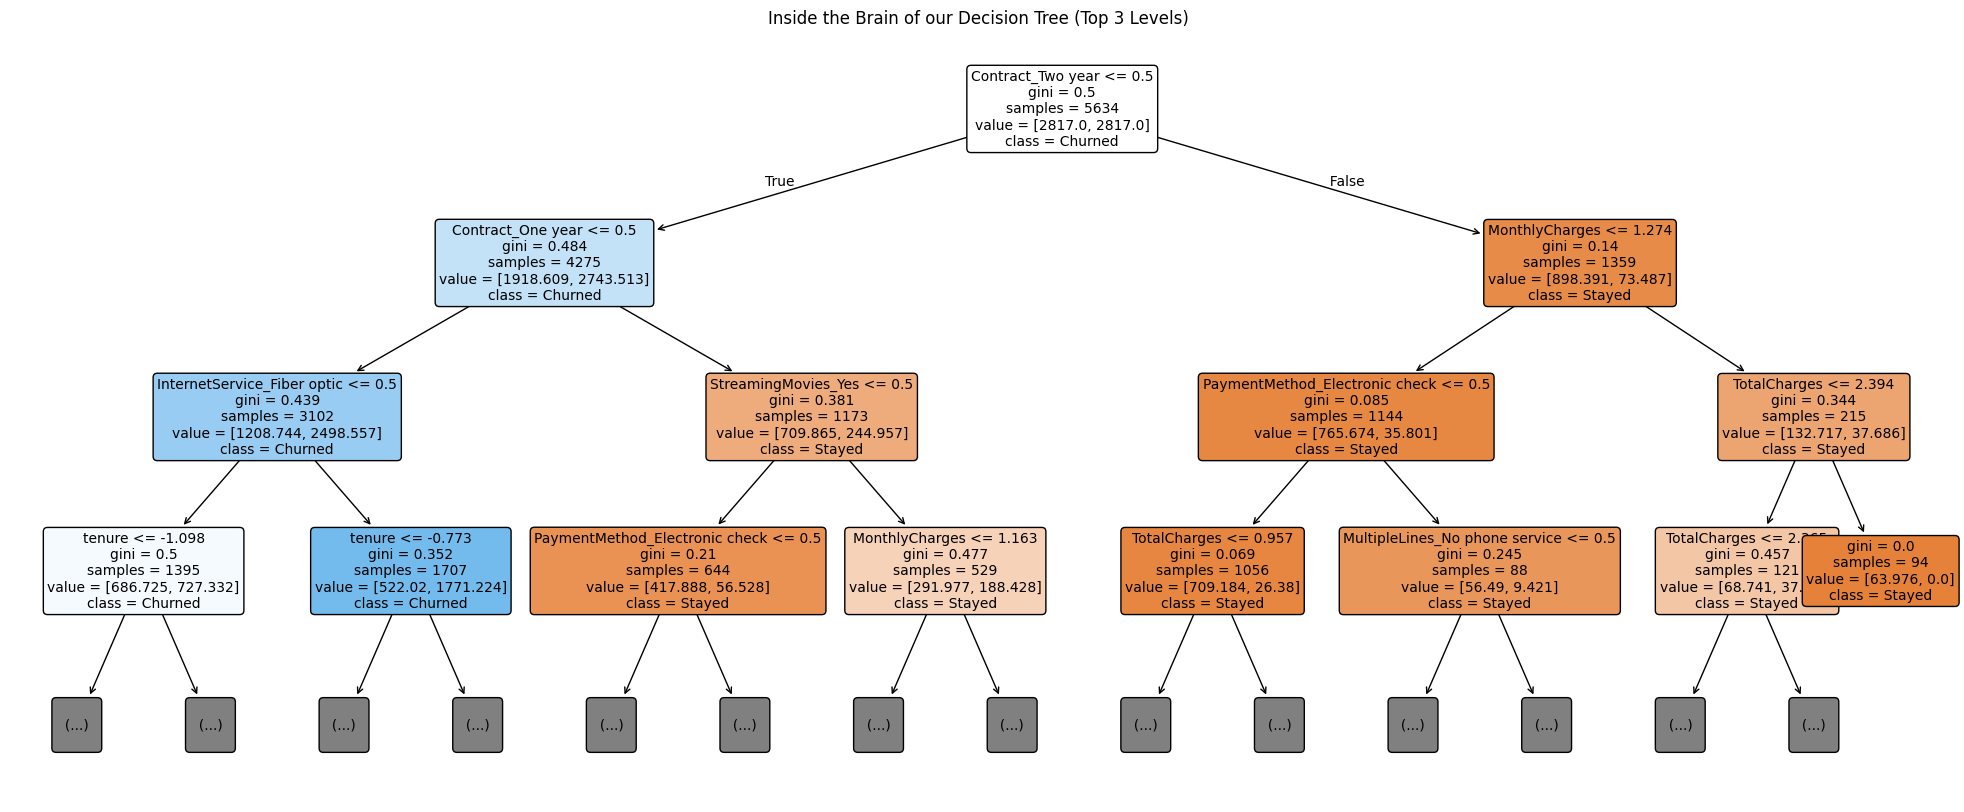

In [17]:
# seeing the tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 10))

# plotting the tree
plot_tree(dt_model,
         feature_names=X_train.columns,
         class_names= ['Stayed', 'Churned'],
         filled=True,
         rounded=True,
         fontsize=10,
         max_depth = 3)
plt.title("Inside the Brain of our Decision Tree (Top 3 Levels)")
plt.show()

## Random Forest Model

In [22]:
from sklearn.ensemble import RandomForestClassifier

# initialize the model
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# train the model
rf_model.fit(X_train, y_train)

# make predictions
y_pred_rf = rf_model.predict(X_test)

# print report card
print("Random Forest Performance:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## GridSearchCV for tuning Random Forest

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth' : [5, 8, 12],
    'n_estimators' : [50, 100],
    'min_samples_split' : [5,10],
    'class_weight': ['balanced', 'balanced_subsample']
}

# initialize a blank baseline model
rf_base = RandomForestClassifier(random_state=42)

# set up grid search cv
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, scoring='recall', n_jobs=-1)

# training on it (takes time)
print("Training dozens of forests... Please wait.")
grid_search.fit(X_train, y_train)

# extract the best model it found
best_rf = grid_search.best_estimator_

# make predictons
y_pred_tuned_rf = best_rf.predict(X_test)

print("\n--- TUNING COMPLETE ---")
print("Winning Settings:", grid_search.best_params_)
print("\nTuned Random Forest Performance:\n")
print(classification_report(y_test, y_pred_tuned_rf))

Training dozens of forests... Please wait.

--- TUNING COMPLETE ---
Winning Settings: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 50}

Tuned Random Forest Performance:

              precision    recall  f1-score   support

           0       0.91      0.70      0.80      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



## XG Boost Classifier

In [25]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import xgboost as xgb

# calculate the weight ratio for imbalance
neg_class_count = len(y_train[y_train==0])
pos_class_count = len(y_train[y_train==1])

scale_weight = neg_class_count/pos_class_count

# initialize the xgboost classifier
xgb_model = xgb.XGBClassifier(
    scale_pos_weight= scale_weight,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

# train that model
xgb_model.fit(X_train, y_train)

# make predictions
y_pred_xgb = xgb_model.predict(X_test)

# print the report card
print("XGBoost Performance :\n")
print(classification_report(y_test,y_pred_xgb))

XGBoost Performance :

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



## GridSearchCV on XGBoost

In [28]:
from sklearn.model_selection import GridSearchCV

# defining parameters
xgb_param_grid = {
    'max_depth' : [3,5,7],
    'learning_rate' : [0.05, 0.1, 0.2],
    'n_estimators' : [100, 200]
}

# initializing base xgboost model
xgb_base = xgb.XGBClassifier(scale_pos_weight= scale_weight, random_state=42)

# set up grid search cv
xgb_grid = GridSearchCV(estimator=xgb_base, param_grid=xgb_param_grid, cv=3, scoring='f1', n_jobs=-1)

# run the tuning
print("Tuning XGBoost... Please wait.")
xgb_grid.fit(X_train, y_train)

# extracting the winner
best_xgb = xgb_grid.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

print("\n--- XGBOOST TUNING COMPLETE ---")
print("Winning Settings:", xgb_grid.best_params_)
print("\nTuned XGBoost Performance:\n")
print(classification_report(y_test, y_pred_best_xgb))

Tuning XGBoost... Please wait.

--- XGBOOST TUNING COMPLETE ---
Winning Settings: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

Tuned XGBoost Performance:

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



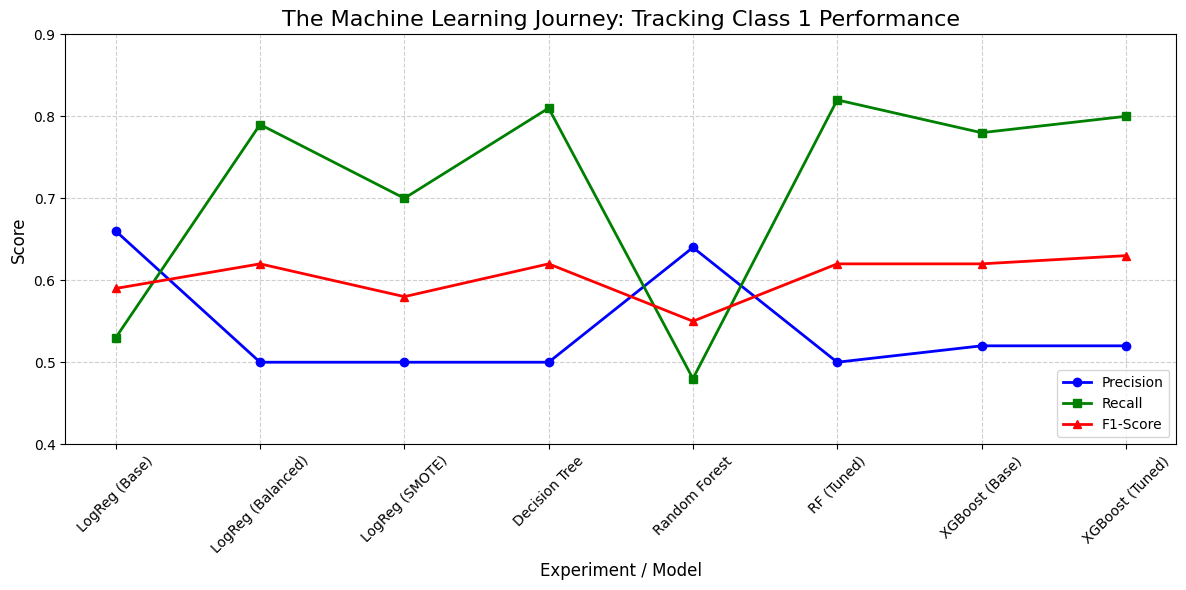

In [29]:
import matplotlib.pyplot as plt

# 1. The names of the models in the order you trained them
models = [
    'LogReg (Base)', 
    'LogReg (Balanced)', 
    'LogReg (SMOTE)', 
    'Decision Tree', 
    'Random Forest', 
    'RF (Tuned)', 
    'XGBoost (Base)', 
    'XGBoost (Tuned)'
]

# 2. The exact Class 1 metrics extracted from your screenshots
precision = [0.66, 0.50, 0.50, 0.50, 0.64, 0.50, 0.52, 0.52]
recall    = [0.53, 0.79, 0.70, 0.81, 0.48, 0.82, 0.78, 0.80]
f1_score  = [0.59, 0.62, 0.58, 0.62, 0.55, 0.62, 0.62, 0.63]

# 3. Set up a large canvas for the chart
plt.figure(figsize=(12, 6))

# 4. Plot each metric as a line with different markers so they are easy to see
plt.plot(models, precision, marker='o', label='Precision', color='blue', linewidth=2)
plt.plot(models, recall, marker='s', label='Recall', color='green', linewidth=2)
plt.plot(models, f1_score, marker='^', label='F1-Score', color='red', linewidth=2)

# 5. Add titles, labels, and clean formatting
plt.title('The Machine Learning Journey: Tracking Class 1 Performance', fontsize=16)
plt.xlabel('Experiment / Model', fontsize=12)
plt.ylabel('Score', fontsize=12)

# Set the y-axis to focus purely on the action (between 0.40 and 0.90)
plt.ylim(0.40, 0.90) 

# Tilt the x-axis labels 45 degrees so the model names don't overlap
plt.xticks(rotation=45) 
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Keep the layout neat and show the plot
plt.tight_layout()
plt.show()

## Feature Importance

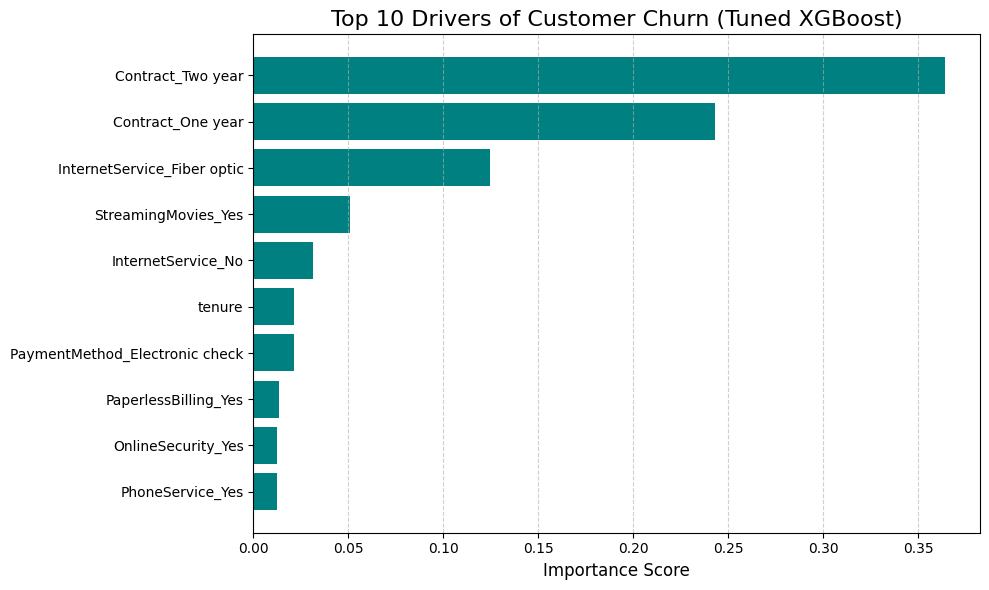

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_

# storing in dataframe
feature_df = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : importances
})

# sorting them
top_10_features = feature_df.sort_values(by='Importance', ascending = True).tail(10)

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='teal')
plt.title('Top 10 Drivers of Customer Churn (Tuned XGBoost)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [32]:
import joblib
import os

# 1. Save the winning XGBoost model
joblib.dump(best_xgb, '../model_artifacts/xgboost_churn_model.pkl')

# 2. Save the StandardScaler
joblib.dump(scaler, '../model_artifacts/churn_scaler.pkl')

print("Model and Scaler successfully saved to the 'model_artifacts' folder!")

Model and Scaler successfully saved to the 'model_artifacts' folder!


In [35]:
import pandas as pd
import numpy as np

# 1. Define the exact 32 columns
model_columns = [
    'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
    'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
    'MultipleLines_No phone service', 'MultipleLines_Yes',
    'InternetService_Fiber optic', 'InternetService_No',
    'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
    'OnlineBackup_No internet service', 'OnlineBackup_Yes',
    'DeviceProtection_No internet service', 'DeviceProtection_Yes',
    'TechSupport_No internet service', 'TechSupport_Yes',
    'StreamingTV_No internet service', 'StreamingTV_Yes',
    'StreamingMovies_No internet service', 'StreamingMovies_Yes',
    'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
    'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check',
    'Tenure_Bucket_Established (13-60m)', 'Tenure_Bucket_Veteran(60m+)'
]

# 2. Create the blank DataFrame
test_df = pd.DataFrame(0, index=[0], columns=model_columns)

# 3. Continuous Features
test_df['tenure'] = 2
test_df['MonthlyCharges'] = 85.0
test_df['TotalCharges'] = 170.0

# 4. Turn on ONLY the specific "1"s for this High Risk customer profile
test_df['SeniorCitizen'] = 1
test_df['PhoneService_Yes'] = 1
test_df['MultipleLines_Yes'] = 1
test_df['InternetService_Fiber optic'] = 1
test_df['PaperlessBilling_Yes'] = 1
test_df['PaymentMethod_Electronic check'] = 1

# Note: All other features remain 0. 
# For example, gender is Female, so 'gender_Male' stays 0. 
# Tenure is 2, so the Tenure_Buckets both stay 0.

# 5. Scale ONLY the continuous columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
test_df[num_cols] = scaler.transform(test_df[num_cols])

# 6. Predict
probability = best_xgb.predict_proba(test_df)[0][1]
prediction = best_xgb.predict(test_df)[0]

print(f"Notebook Prediction: {'Will Churn' if prediction == 1 else 'Will Not Churn'}")
print(f"Notebook Probability: {probability * 100:.2f}%")

Notebook Prediction: Will Churn
Notebook Probability: 91.80%
